# 5 — The health of a network

The third of the three things observability was split into, and the one that
is an **opinion**: the record says what happened, this says what somebody
thinks of it, at thresholds somebody chose.

The line between them is an invariant, and it is what this notebook is really
about:

> **A diagnosis has to be reproducible from the stored record, without
> training again.**

So nothing below trains twice. Each pathology is built, trained once, written
down — and then diagnosed from the store, argued with by moving a bound, and
diagnosed again.

In [1]:
import tempfile

import torch

import soma_next.torch  # noqa: F401
from soma_next import Graph, Node, Opaque, Recorder, Store
from soma_next.health import (
    Thresholds,
    about,
    alerts,
    diagnose,
    flags,
    history,
    overlaid,
    profile,
    seen,
    where,
)
from soma_next.record import gantt, progress
from soma_next.torch import Audit, Trainer, architecture, parameters

torch.manual_seed(0)


class Block(Node):
    """One layer and a non-linearity, which is all any of these need."""

    def __init__(self, width=16, activation="relu", bias=None, gain=None):
        self.net = torch.nn.Linear(width, width)
        if bias is not None:
            torch.nn.init.constant_(self.net.bias, bias)
        if gain is not None:
            with torch.no_grad():
                self.net.weight *= gain
        self.after = {
            "relu": torch.nn.ReLU(),
            "sigmoid": torch.nn.Sigmoid(),
            "tanh": torch.nn.Tanh(),
            "none": torch.nn.Identity(),
        }[activation]

    def forward(self, x, ctx):
        return Opaque(self.after(self.net(x)))

    def parameters(self):
        return list(self.net.parameters())


def chain(blocks):
    named = [block.named(f"b{i}") for i, block in enumerate(blocks)]
    wired = named[0]
    for one in named[1:]:
        wired = wired >> one
    return Graph.somatize(wired)


def trained(g, store, run, *, steps=20, lr=0.05, auditing=True, width=16):
    """One short run, audited and written down. Nothing here is trained twice."""
    t = Trainer(
        g,
        objective=torch.nn.functional.mse_loss,
        optimizer=torch.optim.SGD(parameters(g), lr=lr),
        auditing=auditing,
        watching=Recorder(store, run=run, summarising=["loss"]),
    )
    for _ in range(steps):
        t.step((torch.randn(32, width), torch.randn(32, width)))
    return t


store = Store(tempfile.mkdtemp())

## Measuring is opt-in, and it decides nothing

`auditing=True` puts hooks on every node that holds a torch module. What comes
out is a `health` fact per node per step — **numbers**, in the same record as
the loss — and whether those numbers are bad is somebody else's job.

The cheap half is a handful of reductions on tensors already in memory. The
expensive half is an SVD and runs on a cadence: `Audit(every=4, snapshot=50)`.

## Vanishing is a shape over depth, not a property of a layer

σ′(z) ≤ 0.25 per layer, so with unit-gain init the backpropagated signal
shrinks geometrically with depth. The **early** layers go quiet while the last
one still learns — which is why one number per node says nothing and the
profile says all of it.

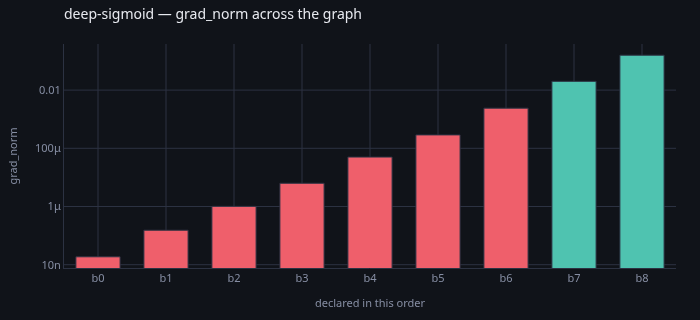

In [2]:
torch.manual_seed(0)
deep = chain([Block(activation="sigmoid") for _ in range(9)])
trained(deep, store, "deep-sigmoid")

profile(store, run="deep-sigmoid", of="grad_norm")

Nine orders of magnitude across nine layers, and it is a straight line on a
log axis — geometric decay, exactly as the theory says.

The same profile in the **update-to-weight ratio** is the more actionable one,
because it has the learning rate in it: it says how far each layer actually
moves per step, against its own size. Practice puts a healthy layer near
`1e-3`, and the dotted line is that.

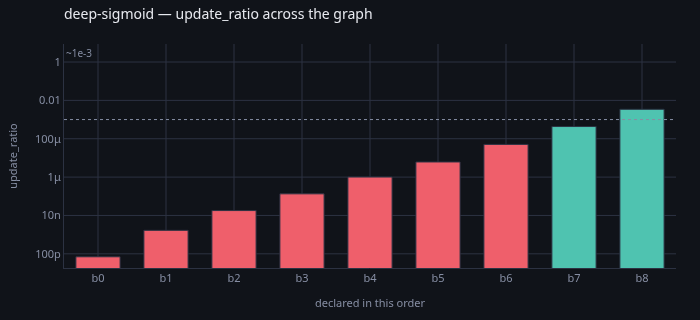

In [3]:
profile(store, run="deep-sigmoid", of="update_ratio")

The last two layers sit on the line and the first seven are between four and
nine orders below it. That number is the cheapest signal in the whole audit,
and the original framework measured it without ever saying anything about it.

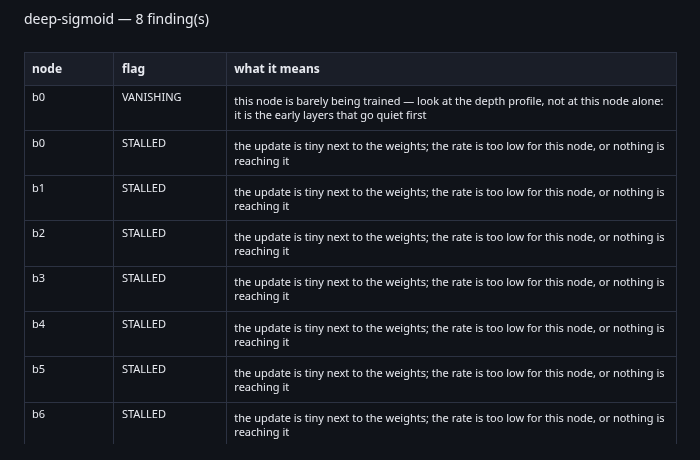

In [4]:
flags(store, run="deep-sigmoid")

### And loudly

A table is for reading; this is for **noticing**. A finding nobody saw is a
finding nobody had, which is why the original framework put these on the
screen as toasts.

In [5]:
alerts(store, run="deep-sigmoid")

deep-sigmoid — 8 finding(s)
  ⚠ b0: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ b0: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ b1: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ b2: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ b3: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ b4: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ b5: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ b6: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it

## The invariant: argue with a bound, do not train again

The verdict is a function of the numbers and the thresholds. Both are data,
and the numbers are already on disk. So a disagreement about where "too small"
begins costs a scan.

In [6]:
strict = diagnose(store, run="deep-sigmoid", thresholds=Thresholds(update_low=1e-2))
lenient = diagnose(store, run="deep-sigmoid", thresholds=Thresholds(update_low=1e-30))
print("strict :", sorted(strict))
print("lenient:", sorted(lenient))

strict : ['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8']
lenient: ['b0']


Same store, same run, no GPU. That is the whole reason the verdict lives in a
crate with no dependencies that cannot measure anything.

In [7]:
print(about("STALLED"))
print(about("VANISHING"))

the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first


## A dying ReLU

A large negative bias puts every pre-activation under zero, so the layer
outputs nothing at all — and `DEAD` reads the **maximum** zero-fraction over
the window and never the mean, because a layer that dies one step in four is
dead and the average is exactly what hides it.

In [8]:
torch.manual_seed(0)
dying = chain([Block(activation="relu", bias=-50.0)])
trained(dying, store, "dying-relu", steps=6)

print(diagnose(store, run="dying-relu"))
print("zero fraction:", seen(store, run="dying-relu")["b0"]["zero_frac_max"])

{'b0': ['VANISHING', 'DEAD', 'STALLED']}
zero fraction: 1.0


## Gradients too big to step on

Four linear layers with the weights multiplied by sixty. Nothing saturates and
nothing dies; the signal simply grows on the way back.

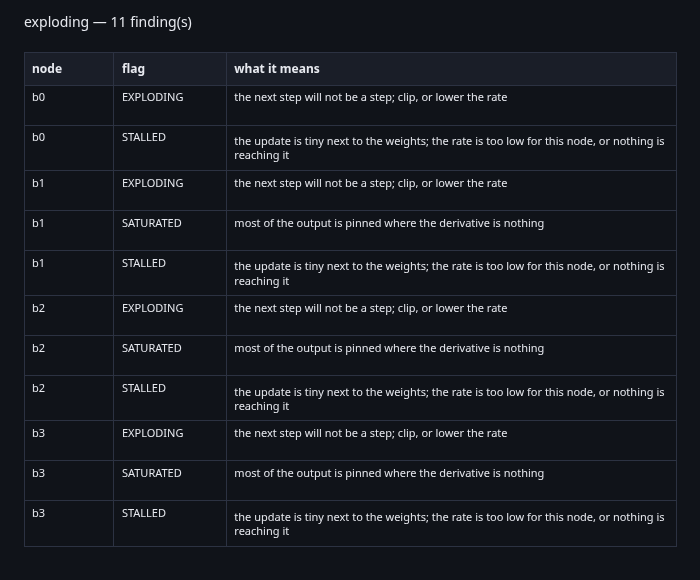

In [9]:
torch.manual_seed(0)
hot = chain([Block(activation="none", gain=60.0) for _ in range(4)])
trained(hot, store, "exploding", steps=4, lr=0.0)

flags(store, run="exploding")

Three things fire here and all three are true, which is worth reading rather
than tidying away. `EXPLODING` is the finding. `SATURATED` follows it — the
activations grow with the same gain that grows the gradients. And `STALLED`
is honest too: this run has a learning rate of zero, so nothing moves at all,
and the update-to-weight ratio says exactly that.

The flags are independent readings of the same network, not a diagnosis
ranked into a single verdict. Ranking them would be this library deciding
which of three true things you meant to ask about.

## And the guard: they may not cry wolf

A detector that fires on a network that is fine is worse than no detector,
because somebody will turn it off. Three tanh blocks and an ordinary rate:

diagnosis: nothing tripped


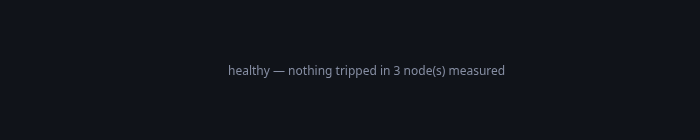

In [10]:
torch.manual_seed(0)
fine = chain([Block(activation="tanh") for _ in range(3)])
trained(fine, store, "healthy", steps=20)

print("diagnosis:", diagnose(store, run="healthy") or "nothing tripped")
flags(store, run="healthy")

Note what that says: **nothing tripped**, which is not the same as *healthy*.
A metric nobody measured cannot raise a flag, and `seen` is what says which
were taken.

In [11]:
seen(store, run="healthy")["b0"]

{'act_abs_mean': 0.38541555404663086,
 'grad_norm': 0.08487989647932544,
 'inf': False,
 'nan': False,
 'param_norm': 2.3461038976063047,
 'param_norm_slope': -0.00015789131175583616,
 'sat_frac_max': 0.0,
 'update_ratio': 0.0018089550357598516,
 'zero_frac_max': 0.0}

## Over time, not just at the end

A verdict is taken over a window, but every number is in the record for every
audited step. `history` is one of them over the run — which is how a gradient
that was fine and stopped being fine becomes visible.

In [12]:
for node in ("b0", "b2"):
    drawn = history(store, run="healthy", node=node, of="grad_norm")
    print(node, [f"{value:.2e}" for _, value in drawn[:5]])

b0 ['8.57e-02', '9.29e-02', '8.59e-02', '8.92e-02', '9.94e-02']
b2 ['1.88e-01', '1.60e-01', '1.40e-01', '1.56e-01', '1.58e-01']


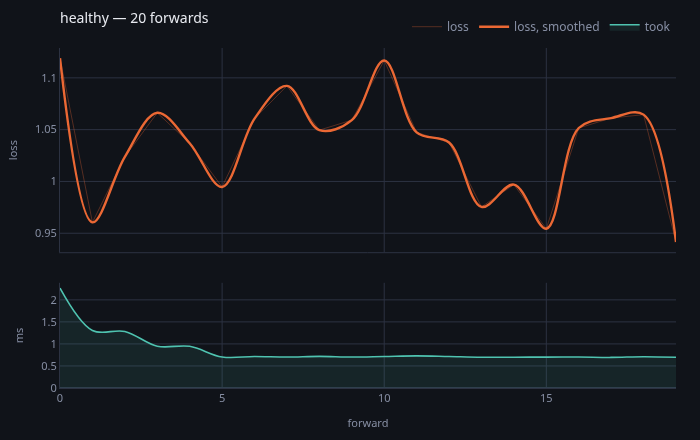

In [13]:
progress(store, run="healthy")

## Inside a node

A node is often a **whole architecture**, and *this node is unhealthy* is not
an answer when the node is twenty layers. `inside=` looks in:

- `inside=True` — the automatic scope: direct children that own parameters,
  descending one level through a single-child wrapper, which is the
  `nn.Sequential` case almost everybody writes;
- `inside={"encoder": 2}` — that many levels down;
- `inside={"encoder": ["net.*"]}` — by name.

In [14]:
class Encoder(Node):
    """Four sigmoid layers in one node, which is where the trouble is hiding."""

    def __init__(self, width=16):
        self.net = torch.nn.Sequential(
            *[m for _ in range(4) for m in (torch.nn.Linear(width, width), torch.nn.Sigmoid())]
        )

    def forward(self, x, ctx):
        return Opaque(self.net(x))

    def parameters(self):
        return list(self.net.parameters())


class Head(Node):
    def __init__(self, width=16):
        self.out = torch.nn.Linear(width, width)

    def forward(self, x, ctx):
        return Opaque(self.out(x))

    def parameters(self):
        return list(self.out.parameters())


torch.manual_seed(0)
deep_inside = Graph.somatize(Encoder().named("encoder") >> Head().named("head"))
trained(deep_inside, store, "inside", auditing=Audit(inside=True), steps=15)

print("measured where:", sorted(seen(store, run="inside")))
diagnose(store, run="inside")

measured where: ['encoder', 'encoder.net.0', 'encoder.net.2', 'encoder.net.4', 'encoder.net.6', 'head', 'head.out']


{'encoder.net.0': ['STALLED'], 'encoder.net.2': ['STALLED']}

`encoder.0` and `encoder.2` — the exact layers, inside the node. The node as a
whole is not flagged, and neither is `head`.

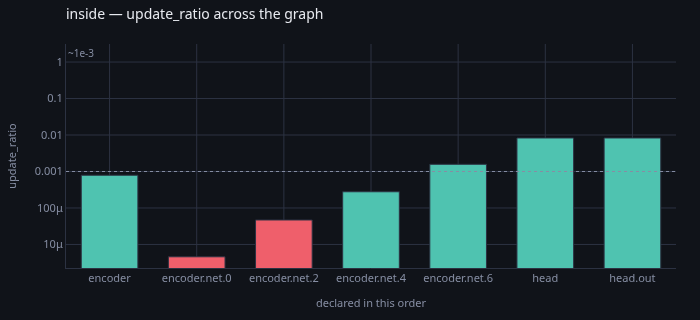

In [15]:
profile(store, run="inside", of="update_ratio")

## And on the graph, which is the answer to *where*

A list of flags says a node is ill. The graph says **which node**, on which
machine, and what feeds it — which is the question a diagnosis of a
distributed graph actually raises.

Health gets a **channel of its own**: the fill goes on saying where a node
runs, the outline turns red, and the flags are a badge under the name.
Recolouring the fill would have let *is this unhealthy* eat *where does this
run*, and on a graph spread over three machines that is the answer somebody
came for.

A finding from inside a node lands on the node — that is the box there is to
mark — and says which layer.

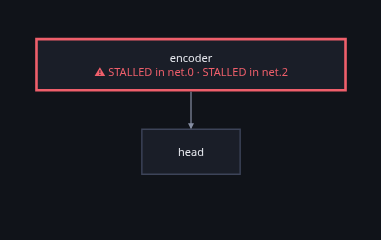

In [16]:
overlaid(deep_inside, store, run="inside")

### And with the node opened up

A cube is not a picture of an architecture. `architecture(g)` reads what each
node is **made of** and hands it to the figure as data — so the drawing knows
nothing about torch, and something that is not torch could answer the same
question about itself.

It draws **everything**, not only what has parameters: a picture of a sigmoid
stack that leaves out the sigmoids is a picture of something else, and *what
the non-linearity is* is the first thing anybody looks for. The audit measures
a subset — a `Sigmoid` has no gradient of its own to report — so every layer
that can carry a flag has a box.

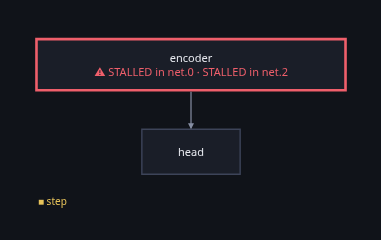

In [17]:
deep_inside.figure(
    inside=architecture(deep_inside),
    overlay={**where(store, run="inside"), **diagnose(store, run="inside")},
)

There it is, and you can **see why**: six layers alternating `Linear` and
`Sigmoid`, with the first two Linears in red. That is a vanishing profile
drawn as the thing that causes it.

## Profiling: what ran when

`spent` says a node cost four hundred milliseconds. It cannot say whether
those four hundred were **beside** the rest of the graph or in front of it,
which is the difference between a slow node and a bottleneck.

Every fact carries how far into the `forward` it started, so a `Wave` draws as
overlapping bars and a `Sequence` as a staircase.

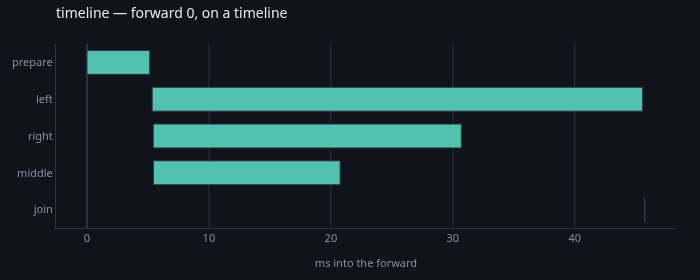

In [18]:
import time


class Waits(Node):
    def __init__(self, ms):
        self.ms = ms

    def forward(self, x, ctx):
        time.sleep(self.ms / 1000.0)
        return self.ms


class Adds(Node):
    def forward(self, said, ctx):
        return sum(said.values())


shaped = Graph.somatize(
    Waits(5).named("prepare")
    >> (Waits(40).named("left") | Waits(15).named("middle") | Waits(25).named("right"))
    >> Adds().named("join")
)
shaped.forward(0.0, watching=Recorder(store, run="timeline"))

gantt(store, run="timeline", forward=0)

Three bars starting together and ending apart: that is a wave, and `left` is
the one the whole thing waits for. Making `middle` twice as fast would buy
nothing at all.

A slice that runs on **another machine** draws in its own colour, inside the
round trip it arrived under — so the gap between the two is the wire.

## What is not here

**The static half.** Everything above needs a training run: it diagnoses what
happened. What a graph can be told about itself *before* a GPU is spent —
signal propagation at init, where a normalisation layer is missing, the
zero-cost proxies that rank architectures without training them — is the next
slice, and it is a different question with different literature behind it.

**The overlay.** The graph figure from notebook 1, coloured by what these
flags say. It needs a channel of its own: in every other figure in this
library hue says *where a node runs* and never good-or-bad, and health is not
allowed to recolour that.

**`NARROWING`**, which is in the vocabulary and off by default. The literature
monitors the spectrum of the weight update and finds it collapses thousands of
steps before the loss does — but its certificate is the deviation from a
healthy baseline run, and one training run has none. Measured against its own
history: healthy runs dipped to 0.69 of their own median and destabilised ones
ranged 0.43–0.86, which overlaps in both directions. The metric is recorded
and can be drawn; the alarm was not invented. The measurement is in
`health/tests/narrowing.py`.